In [ ]:

import tensorflow as tf
from tensorflow import keras
import matplotlib as plt


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [ ]:
data = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    data.data, data.target
)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

In [ ]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)   # learn from train
X_valid = scaler.transform(X_valid)       # apply same scaling
X_test  = scaler.transform(X_test)        # apply same scaling


In [ ]:
model = keras.models.Sequential([
keras.layers.Dense(128, activation="relu"),
keras.layers.Dense(64, activation="relu"),
keras.layers.Dense(32, activation="relu"),
keras.layers.Dense(1),
])

model.compile(loss="mean_squared_error", optimizer="Adam",metrics=["mae"])





In [ ]:
# Functional Model (Wide & Deep)


input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation='relu')(input_)
hidden2 = keras.layers.Dense(30, activation='relu')(hidden1)
concat = keras.layers.Concatenate()([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.Model(inputs=[input_], outputs=[output])

model.compile(loss="mean_squared_error", optimizer="Adam",metrics=["mae"])


In [ ]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import concatenate

# Functional Model (Multi input MLP)

input_1 = Input(shape=[5], name="wide_input")
input_2 = Input(shape=[6], name="deep_input")


(11610,)

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.6027 - mae: 0.9491 - val_loss: 0.7009 - val_mae: 0.6541
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5956 - mae: 0.5726 - val_loss: 0.5713 - val_mae: 0.5538
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5566 - mae: 0.5470 - val_loss: 0.5474 - val_mae: 0.5575
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5334 - mae: 0.5334 - val_loss: 0.5440 - val_mae: 0.5209
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5166 - mae: 0.5225 - val_loss: 0.5028 - val_mae: 0.5247
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4939 - mae: 0.5080 - val_loss: 0.4895 - val_mae: 0.5029
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4818 - mae: 0.4991 - val_loss: 0.5130 - val_mae: 0.4906
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4703 - mae: 0.4908 - val_loss: 0.4614 - val_mae: 0.4996
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

<Axes: >

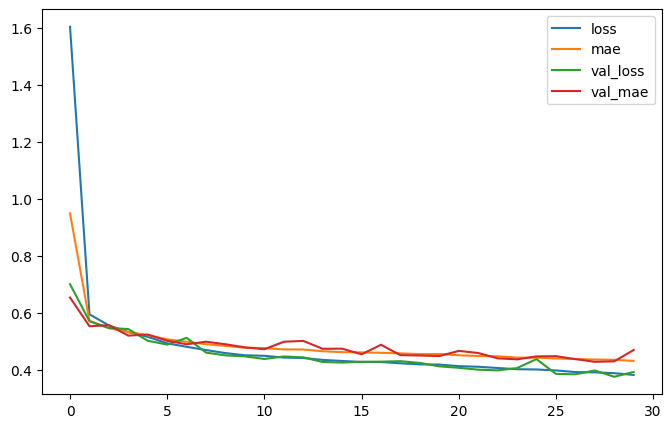

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))
pd.DataFrame(history.history).plot(figsize=(8,5))




In [ ]:
model.evaluate(X_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4130 - mae: 0.4682


[0.4129946231842041, 0.4682144522666931]

In [ ]:
import pandas as pd

y_train_series = pd.Series(y_train)
print(y_train_series.describe())



count    11610.000000
mean         2.062245
std          1.156632
min          0.149990
25%          1.188000
50%          1.792000
75%          2.633750
max          5.000010
dtype: float64
